In [1]:
# Cell 1  imports and basic configuration

import os
import math
import gc
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, TensorDataset, Sampler
import matplotlib.pyplot as plt
from tqdm import tqdm

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    HAS_FID = True
except Exception:
    HAS_FID = False

DATA_ROOT = Path("./data")
MODEL_ROOT = Path("./models") / "figure5"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

torch.backends.cudnn.benchmark = True


def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [2]:
# Cell 2  model definition

def softplus_inv(y):
    # Stable inverse softplus
    if torch.is_tensor(y):
        return torch.where(y > 20.0, y, torch.log(torch.expm1(y)))
    else:
        return y if y > 20.0 else math.log(math.expm1(y))

class WitnessScoreCrossAttention(nn.Module):
    def __init__(self, witness_tensor: torch.Tensor):
        super().__init__()
        self.register_buffer("W", witness_tensor.float())

    @staticmethod
    def _pairwise_scores(x, tx, kernel="std"):
        batch, tokens, dim = x.shape

        x2 = (x ** 2).sum(dim=-1, keepdim=True)
        dot = torch.matmul(x, x.transpose(-1, -2))
        dist2 = -2.0 * dot
        if kernel == "rbf":
            dist2 = dist2 + x2 + x2.transpose(-2, -1)
        
        # Clamp in-place to save memory and prevent NaNs
        dist2.clamp_(min=0.0)

        scale = tx.view(1, tokens, 1)
        weights = torch.softmax(-0.5 * dist2 * scale, dim=-1)

        mask = torch.eye(tokens, dtype=torch.bool, device=x.device).unsqueeze(0)
        weights = weights.masked_fill(mask, 0.0)

        exp_x = torch.matmul(weights, x)
        score = -(x - exp_x) * scale
        return score

    def forward(self, x, tW_vec, tx_vec, kernel="std"):
        batch, tokens, dim = x.shape
        W = self.W.to(x.dtype)

        x2 = (x ** 2).sum(dim=-1, keepdim=True)
        W2 = (W ** 2).sum(dim=-1)

        # Cross term (Heavy memory usage)
        cross = torch.matmul(x, W.transpose(0, 1))
        
        dist2 = x2 + W2.view(1, 1, -1) - 2.0 * cross
        
        # Clamp in-place to save memory and prevent NaNs
        dist2.clamp_(min=0.0)

        tW_scale = tW_vec.view(1, tokens, 1)
        weights = torch.softmax(-0.5 * dist2 * tW_scale, dim=-1)
        exp_W = torch.matmul(weights, W)

        W_score = -(x - exp_W) * tW_scale
        x_score = self._pairwise_scores(x, tx_vec, kernel)

        return W_score, x_score


class LStepDenoiserMultiple(nn.Module):
    def __init__(
        self,
        num_layers,
        witness_tensor,
        t_start=1.5,
        t_end=0.02,
        kernel="rbf",
    ):
        super().__init__()

        self.scores = nn.ModuleList(
            [WitnessScoreCrossAttention(witness_tensor) for _ in range(num_layers)]
        )
        self.kernel = kernel

        t_lin = torch.linspace(t_start, t_end, num_layers)
        dt_lin = torch.cat(
            [t_lin[1:] - t_lin[:-1], t_lin[-1:] - t_lin[-2:-1]]
        ) / 2.0

        # Use stable init to prevent exp explosion
        scale_schedule = 1.0 / (t_lin ** 2)
        
        self.tW_raw = nn.Parameter(softplus_inv(scale_schedule)[:, None].repeat(1, 2))
        self.tx_raw = nn.Parameter(softplus_inv(scale_schedule)[:, None].repeat(1, 2))
        
        # dt is negative, so we init with -dt to keep softplus positive
        self.dtW_raw = nn.Parameter(softplus_inv(-dt_lin)[:, None].repeat(1, 2))
        self.dtx_raw = nn.Parameter(softplus_inv(-dt_lin)[:, None].repeat(1, 2))

        self.do_icl = True

    def times_and_steps(self):
        tW = F.softplus(self.tW_raw)
        dtW = -F.softplus(self.dtW_raw) # dt is negative
        tx = F.softplus(self.tx_raw)
        dtx = -F.softplus(self.dtx_raw) # dt is negative
        return tW, dtW, tx, dtx

    def forward(self, x0, first_layer=0):
        # x0 shape batch by tokens by dim
        tW, dtW, tx, dtx = self.times_and_steps()
        tokens = x0.shape[1]
        x = x0
        traj = [x.clone()]
        num_layers = len(self.scores)

        for layer in range(first_layer, num_layers):
            # Index 0 is Query. Indices 1..N are Context.
            
            dtW_vec = torch.cat((
                dtW[layer, 1].repeat(1),           # Query (Index 0)
                dtW[layer, 0].repeat(tokens - 1)   # Context (Index 1+)
            )).to(x0.device)

            tW_vec = torch.cat((
                tW[layer, 1].repeat(1),
                tW[layer, 0].repeat(tokens - 1)
            )).to(x0.device)

            dtx_vec = torch.cat((
                dtx[layer, 1].repeat(1),
                dtx[layer, 0].repeat(tokens - 1)
            )).to(x0.device)

            tx_vec = torch.cat((
                tx[layer, 1].repeat(1),
                tx[layer, 0].repeat(tokens - 1)
            )).to(x0.device)

            W_score, x_score = self.scores[layer](x, tW_vec, tx_vec, self.kernel)
            
            # Compute full update vector
            step = dtW_vec.view(1, tokens, 1) * W_score
            if self.do_icl:
                step = step + dtx_vec.view(1, tokens, 1) * x_score
            
            # FIX: Out-of-place update to satisfy Autograd
            # We update Query (index 0) but keep Context (indices 1:) frozen from previous step
            
            # 1. Extract query and update it
            query_new = x[:, 0:1] - step[:, 0:1]
            
            # 2. Concatenate with the frozen context
            # We re-use x[:, 1:] directly. Since we don't modify it in-place, 
            # autograd is happy.
            x = torch.cat([query_new, x[:, 1:]], dim=1)
            
            traj.append(x.clone())

        return x, traj

In [3]:
# Cell 3  helper sampler for same class context

class SameClassBatchSampler(Sampler):
    def __init__(
        self,
        labels: torch.Tensor,
        context_length: int,
        batch_size: int,
        generator: torch.Generator,
        shuffle: bool = True,
    ):
        super().__init__(None)
        self.labels = labels.detach().cpu()
        self.context_length = max(int(context_length), 1)
        self.batch_size = int(batch_size)
        self.generator = generator
        self.shuffle = shuffle
        self.steps = len(self.labels) // self.batch_size
        self._build_index()

    def _build_index(self):
        context = self.context_length
        labels = self.labels

        classes = torch.unique(labels).tolist()
        buckets = {c: torch.where(labels == c)[0] for c in classes}

        blocks = []
        for idx in buckets.values():
            if self.shuffle:
                idx = idx[torch.randperm(len(idx), generator=self.generator)]
            usable = idx[: (len(idx) // context) * context]
            if usable.numel() == 0:
                continue
            blocks.append(usable.view(-1, context))

        if not blocks:
            raise ValueError("Not enough samples to form context blocks")

        all_blocks = torch.cat(blocks, dim=0)
        if self.shuffle:
            all_blocks = all_blocks[
                torch.randperm(len(all_blocks), generator=self.generator)
            ]

        flat = all_blocks.flatten()
        need = self.steps * self.batch_size
        self.indices = flat[:need]

    def __iter__(self):
        if self.shuffle:
            self._build_index()
        for step in range(self.steps):
            start = step * self.batch_size
            end = start + self.batch_size
            yield self.indices[start:end].tolist()

    def __len__(self):
        return self.steps


In [4]:
# Cell 4  dataset caches for mnist cifar10 cifar100

MNIST_CACHE = None
CIFAR10_CACHE = None
CIFAR100_CACHE = None


def get_mnist_data():
    global MNIST_CACHE
    if MNIST_CACHE is not None:
        return MNIST_CACHE

    transform_flat = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: x.view(-1)),
        ]
    )

    ds = torchvision.datasets.MNIST(
        root=str(DATA_ROOT),
        train=True,
        download=True,
        transform=transform_flat,
    )

    imgs = torch.stack([x for x, _ in ds]).to(device=device, dtype=DTYPE)
    labels = torch.tensor([y for _, y in ds], device=device, dtype=torch.long)

    split = int(0.9 * len(imgs))
    train_imgs = imgs[:split]
    test_imgs = imgs[split:]
    train_labels = labels[:split]
    test_labels = labels[split:]

    train_set = TensorDataset(train_imgs, train_labels)
    test_set = TensorDataset(test_imgs, test_labels)

    witness = train_imgs
    dim = imgs.shape[1]

    cache = {
        "train_set": train_set,
        "test_set": test_set,
        "train_imgs": train_imgs,
        "test_imgs": test_imgs,
        "train_labels": train_labels,
        "test_labels": test_labels,
        "witness": witness,
        "dim": dim,
    }
    MNIST_CACHE = cache
    return cache


def get_cifar10_data():
    global CIFAR10_CACHE
    if CIFAR10_CACHE is not None:
        return CIFAR10_CACHE

    transform_flat = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: x.view(-1)),
        ]
    )

    ds = torchvision.datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=True,
        transform=transform_flat,
    )

    imgs = torch.stack([x for x, _ in ds]).to(device=device, dtype=DTYPE)
    labels = torch.tensor([y for _, y in ds], device=device, dtype=torch.long)

    split = int(0.9 * len(imgs))
    train_imgs = imgs[:split]
    test_imgs = imgs[split:]
    train_labels = labels[:split]
    test_labels = labels[split:]

    train_set = TensorDataset(train_imgs, train_labels)
    test_set = TensorDataset(test_imgs, test_labels)

    witness = train_imgs
    dim = imgs.shape[1]

    cache = {
        "train_set": train_set,
        "test_set": test_set,
        "train_imgs": train_imgs,
        "test_imgs": test_imgs,
        "train_labels": train_labels,
        "test_labels": test_labels,
        "witness": witness,
        "dim": dim,
    }
    CIFAR10_CACHE = cache
    return cache


def get_cifar100_data():
    global CIFAR100_CACHE
    if CIFAR100_CACHE is not None:
        return CIFAR100_CACHE

    transform_flat = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: x.view(-1)),
        ]
    )

    ds = torchvision.datasets.CIFAR100(
        root=str(DATA_ROOT),
        train=True,
        download=True,
        transform=transform_flat,
    )

    imgs = torch.stack([x for x, _ in ds]).to(device=device, dtype=DTYPE)
    labels = torch.tensor([y for _, y in ds], device=device, dtype=torch.long)

    split = int(0.9 * len(imgs))
    train_imgs = imgs[:split]
    test_imgs = imgs[split:]
    train_labels = labels[:split]
    test_labels = labels[split:]

    train_set = TensorDataset(train_imgs, train_labels)
    test_set = TensorDataset(test_imgs, test_labels)

    witness = train_imgs
    dim = imgs.shape[1]

    cache = {
        "train_set": train_set,
        "test_set": test_set,
        "train_imgs": train_imgs,
        "test_imgs": test_imgs,
        "train_labels": train_labels,
        "test_labels": test_labels,
        "witness": witness,
        "dim": dim,
    }
    CIFAR100_CACHE = cache
    return cache


In [5]:
# Cell 5  hyper parameters and context grids

NUM_LAYERS = 6

MNIST_CONTEXTS = [0, 2, 4, 28, 42, 56, 63, 84, 105]
MNIST_GLOBAL_BATCH = 2520
MNIST_NOISE_STD = 5.0


def mnist_epochs_for_context(ctx_effective):
    base_epochs = 15
    scale = 10
    if ctx_effective <= 1:
        return base_epochs
    return int(base_epochs + scale * math.log2(ctx_effective))


CIFAR10_CONTEXTS = [0, 2, 8, 16, 32, 60]
CIFAR10_GLOBAL_BATCH = 2400
CIFAR10_NOISE_STD = 2.0
CIFAR10_EPOCH_MAP = {1: 15, 2: 40, 8: 90, 16: 115, 32: 140, 60: 500}


def cifar10_epochs_for_context(ctx_effective):
    if ctx_effective in CIFAR10_EPOCH_MAP:
        return CIFAR10_EPOCH_MAP[ctx_effective]
    base_epochs = 15
    scale = 25
    if ctx_effective <= 1:
        return base_epochs
    return int(base_epochs + scale * math.log2(ctx_effective))


CIFAR100_CONTEXTS = [0, 2, 8, 16, 32, 48]
CIFAR100_GLOBAL_BATCH = 2016
CIFAR100_NOISE_STD = 2.0
CIFAR100_EPOCH_MAP = {1: 15, 2: 40, 8: 90, 16: 115, 32: 200, 48: 300}


def cifar100_epochs_for_context(ctx_effective):
    if ctx_effective in CIFAR100_EPOCH_MAP:
        return CIFAR100_EPOCH_MAP[ctx_effective]
    base_epochs = 15
    scale = 25
    if ctx_effective <= 1:
        return base_epochs
    return int(base_epochs + scale * math.log2(ctx_effective))



SEED_VALUES = [0,1,2]

AXIS_FONT_SIZE = 18
LABEL_FONT_SIZE = 12
TITLE_FONT_SIZE = 24


In [6]:
# Cell 6  loader builders for each dataset

def make_mnist_loaders(context_length):
    data = get_mnist_data()
    train_set = data["train_set"]
    test_set = data["test_set"]
    train_labels = data["train_labels"]
    test_labels = data["test_labels"]
    dim = data["dim"]

    ctx = max(int(context_length), 1)
    batch_size = MNIST_GLOBAL_BATCH
    if batch_size % ctx != 0:
        raise ValueError("MNIST batch size must be divisible by context length")

    generator = torch.Generator()
    generator.manual_seed(1234)

    if ctx == 1:
        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
        )
    else:
        sampler_train = SameClassBatchSampler(
            labels=train_labels,
            context_length=ctx,
            batch_size=batch_size,
            generator=generator,
            shuffle=True,
        )
        train_loader = DataLoader(
            train_set,
            batch_sampler=sampler_train,
        )

    sampler_test = SameClassBatchSampler(
        labels=test_labels,
        context_length=ctx,
        batch_size=batch_size,
        generator=generator,
        shuffle=True,
    )
    test_loader = DataLoader(
        test_set,
        batch_sampler=sampler_test,
    )

    return train_loader, test_loader, ctx, dim


def make_cifar10_loaders(context_length):
    data = get_cifar10_data()
    train_set = data["train_set"]
    test_set = data["test_set"]
    train_labels = data["train_labels"]
    test_labels = data["test_labels"]
    dim = data["dim"]

    ctx = max(int(context_length), 1)
    batch_size = CIFAR10_GLOBAL_BATCH
    if batch_size % ctx != 0:
        raise ValueError("CIFAR-10 batch size must be divisible by context length")

    generator = torch.Generator()
    generator.manual_seed(1234)

    if ctx == 1:
        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
        )
    else:
        sampler_train = SameClassBatchSampler(
            labels=train_labels,
            context_length=ctx,
            batch_size=batch_size,
            generator=generator,
            shuffle=True,
        )
        train_loader = DataLoader(
            train_set,
            batch_sampler=sampler_train,
        )

    sampler_test = SameClassBatchSampler(
        labels=test_labels,
        context_length=ctx,
        batch_size=batch_size,
        generator=generator,
        shuffle=True,
    )
    test_loader = DataLoader(
        test_set,
        batch_sampler=sampler_test,
    )

    return train_loader, test_loader, ctx, dim


def make_cifar100_loaders(context_length):
    data = get_cifar100_data()
    train_set = data["train_set"]
    test_set = data["test_set"]
    train_labels = data["train_labels"]
    test_labels = data["test_labels"]
    dim = data["dim"]

    ctx = max(int(context_length), 1)
    batch_size = CIFAR100_GLOBAL_BATCH
    if batch_size % ctx != 0:
        raise ValueError("CIFAR-100 batch size must be divisible by context length")

    generator = torch.Generator()
    generator.manual_seed(1234)

    if ctx == 1:
        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
        )
    else:
        sampler_train = SameClassBatchSampler(
            labels=train_labels,
            context_length=ctx,
            batch_size=batch_size,
            generator=generator,
            shuffle=True,
        )
        train_loader = DataLoader(
            train_set,
            batch_sampler=sampler_train,
        )

    sampler_test = SameClassBatchSampler(
        labels=test_labels,
        context_length=ctx,
        batch_size=batch_size,
        generator=generator,
        shuffle=True,
    )
    test_loader = DataLoader(
        test_set,
        batch_sampler=sampler_test,
    )

    return train_loader, test_loader, ctx, dim


In [7]:
# Cell 7  train and checkpoint helpers

def build_model_for_dataset(dataset_name, witness_tensor):
    model = LStepDenoiserMultiple(
        num_layers=NUM_LAYERS,
        witness_tensor=witness_tensor,
        t_start=1.5,
        t_end=0.02,
        kernel="rbf",
    ).to(device)
    return model


def slim_state_dict(model):
    # keep schedule and all trainable weights
    # drop large witness buffers since they come from the constructor
    state = model.state_dict()
    slim = {k: v for k, v in state.items() if not k.endswith(".W")}
    return slim


def rmse_single_token(model, loader, context_length, noise_std, dim):
    model.eval()
    ctx = max(int(context_length), 1)
    sum_sq = 0.0
    count = 0

    use_amp = (device.type == "cuda")

    with torch.no_grad():
        if use_amp:
            autocast_context = torch.cuda.amp.autocast(dtype=DTYPE)
        else:
            autocast_context = torch.cuda.amp.autocast(enabled=False)

        with autocast_context:
            for batch in loader:
                clean_flat, _ = batch
                clean_flat = clean_flat.to(device=device, dtype=DTYPE)
                clean = clean_flat.view(-1, ctx, dim)

                noisy = clean.clone()
                noisy[:, 0, :] = noisy[:, 0, :] + torch.randn_like(
                    noisy[:, 0, :]
                ) * noise_std

                recon, _ = model(noisy)
                error = recon[:, 0, :] - clean[:, 0, :]
                sum_sq += error.pow(2).sum().item()
                count += error.shape[0]

    rmse = math.sqrt(sum_sq / max(count, 1))
    return rmse


def train_model_for_dataset(
    dataset_name,
    context_length,
    seed,
    reuse_checkpoint=True,
):
    if dataset_name == "mnist":
        data = get_mnist_data()
        witness = data["witness"]
        train_loader, _, ctx_eff, dim = make_mnist_loaders(context_length)
        noise_std = MNIST_NOISE_STD
        epochs = mnist_epochs_for_context(ctx_eff)
        model_dir = MODEL_ROOT / "mnist"
        lr = 5e-2
    elif dataset_name == "cifar10":
        data = get_cifar10_data()
        witness = data["witness"]
        train_loader, _, ctx_eff, dim = make_cifar10_loaders(context_length)
        noise_std = CIFAR10_NOISE_STD
        epochs = cifar10_epochs_for_context(ctx_eff)
        model_dir = MODEL_ROOT / "cifar10"
        lr = 5e-2
    elif dataset_name == "cifar100":
        data = get_cifar100_data()
        witness = data["witness"]
        train_loader, _, ctx_eff, dim = make_cifar100_loaders(context_length)
        noise_std = CIFAR100_NOISE_STD
        epochs = cifar100_epochs_for_context(ctx_eff)
        model_dir = MODEL_ROOT / "cifar100"
        lr = 5e-2
    else:
        raise ValueError("Unknown dataset name")

    model_dir.mkdir(parents=True, exist_ok=True)
    ctx_tag = int(context_length)
    ckpt_path = model_dir / f"denoiser_ctx{ctx_tag}_seed{seed}.pt"

    data_cache = {"witness": witness, "dim": dim}

    # try to load existing weights
    if reuse_checkpoint and ckpt_path.exists():
        model = build_model_for_dataset(dataset_name, witness)
        state = torch.load(str(ckpt_path), map_location=device)
        # allow slim checkpoints with missing witness buffers
        model.load_state_dict(state, strict=False)
        model.do_icl = (context_length > 0)
        return model, data_cache

    # train new model when no checkpoint is available
    set_random_seed(seed)

    model = build_model_for_dataset(dataset_name, witness)
    model.do_icl = (context_length > 0)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.9))
    scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs * len(train_loader),
        eta_min=1e-3,
    )

    use_amp = (device.type == "cuda")

    for epoch in range(epochs):
        bar = tqdm(
            train_loader,
            desc=f"{dataset_name} ctx {context_length} seed {seed} epoch {epoch + 1} of {epochs}",
            leave=False,
        )
        for batch in bar:
            clean_flat, _ = batch
            clean_flat = clean_flat.to(device=device, dtype=DTYPE)
            clean = clean_flat.view(-1, max(int(context_length), 1), dim)

            noisy = clean.clone()
            noisy[:, 0, :] = noisy[:, 0, :] + torch.randn_like(
                noisy[:, 0, :]
            ) * noise_std

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast(dtype=DTYPE):
                    recon, _ = model(noisy)
                    error = recon[:, 0, :] - clean[:, 0, :]
                    mse = error.pow(2).sum(dim=1).mean()
                scaler.scale(mse).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                recon, _ = model(noisy)
                error = recon[:, 0, :] - clean[:, 0, :]
                mse = error.pow(2).sum(dim=1).mean()
                mse.backward()
                optimizer.step()

            scheduler.step()

        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    # save slim checkpoint that omits witness buffers
    torch.save(slim_state_dict(model), str(ckpt_path))

    return model, data_cache


In [ ]:
# Cell 8  rmse sweeps for mnist cifar10 cifar100

def rmse_curve_for_dataset(dataset_name, contexts):
    means = []
    stds = []
    per_context_per_seed = {}

    for ctx in contexts:
        values = []
        for seed in SEED_VALUES:
            model, data_cache = train_model_for_dataset(
                dataset_name=dataset_name,
                context_length=ctx,
                seed=seed,
                reuse_checkpoint=True,
            )
            dim = data_cache["dim"]

            if dataset_name == "mnist":
                _, test_loader, ctx_eff, _ = make_mnist_loaders(ctx)
                noise_std = MNIST_NOISE_STD
            elif dataset_name == "cifar10":
                _, test_loader, ctx_eff, _ = make_cifar10_loaders(ctx)
                noise_std = CIFAR10_NOISE_STD
            elif dataset_name == "cifar100":
                _, test_loader, ctx_eff, _ = make_cifar100_loaders(ctx)
                noise_std = CIFAR100_NOISE_STD
            else:
                raise ValueError("Unknown dataset name")

            rmse = rmse_single_token(
                model=model,
                loader=test_loader,
                context_length=ctx_eff,
                noise_std=noise_std,
                dim=dim,
            )
            values.append(rmse)

            del model
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

        values_arr = np.asarray(values, dtype=np.float64)
        per_context_per_seed[int(ctx)] = values_arr.copy()
        means.append(values_arr.mean())
        stds.append(values_arr.std(ddof=1) if len(values_arr) > 1 else 0.0)

        print(
            f"{dataset_name} context {ctx}  mean {means[-1]:.4f}  std {stds[-1]:.4f}  seeds {len(values_arr)}"
        )

    contexts_arr = np.asarray(contexts, dtype=np.int64)
    means_arr = np.asarray(means, dtype=np.float64)
    stds_arr = np.asarray(stds, dtype=np.float64)
    return contexts_arr, means_arr, stds_arr, per_context_per_seed


print("Running RMSE sweeps")

mnist_x, mnist_mu, mnist_sigma, mnist_raw = rmse_curve_for_dataset(
    "mnist", MNIST_CONTEXTS
)
c10_x, c10_mu, c10_sigma, c10_raw = rmse_curve_for_dataset(
    "cifar10", CIFAR10_CONTEXTS
)
c100_x, c100_mu, c100_sigma, c100_raw = rmse_curve_for_dataset(
    "cifar100", CIFAR100_CONTEXTS
)


Running RMSE sweeps
mnist context 0  mean 13.2856  std 1.6014  seeds 3
mnist context 2  mean 8.0201  std 0.0891  seeds 3
mnist context 4  mean 7.1863  std 0.0113  seeds 3


mnist context 28  mean 7.2188  std 0.1040  seeds 3


mnist context 42  mean 7.2180  std 0.0050  seeds 3


mnist ctx 56 seed 1 epoch 37 of 73:  57%|█████▋    | 12/21 [00:03<00:02,  3.55it/s]

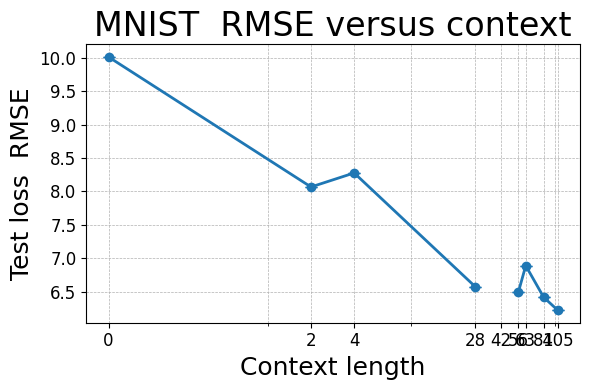

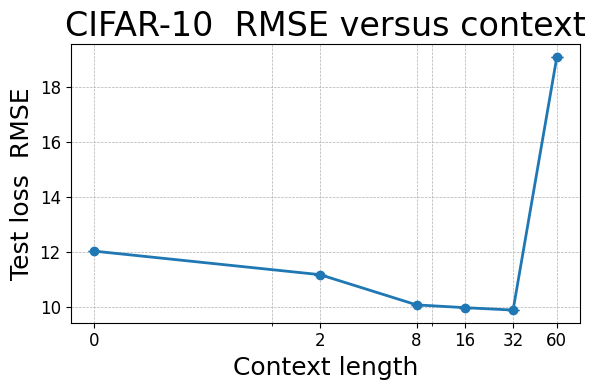

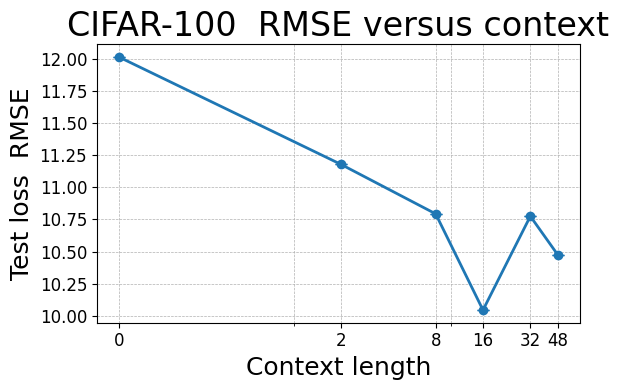

MNIST RMSE table
 context      mean  std
       0 10.014484  0.0
       2  8.066763  0.0
       4  8.276927  0.0
      28  6.572194  0.0
      42       NaN  0.0
      56  6.493791  0.0
      63  6.887353  0.0
      84  6.414573  0.0
     105  6.222170  0.0

CIFAR  RMSE table
 context      mean  std
       0 12.039767  0.0
       2 11.180258  0.0
       8 10.080853  0.0
      16  9.978836  0.0
      32  9.891380  0.0
      60 19.108048  0.0

CIFAR one hundred RMSE table
 context      mean  std
       0 12.015637  0.0
       2 11.179135  0.0
       8 10.793741  0.0
      16 10.044078  0.0
      32 10.775200  0.0
      48 10.471601  0.0


In [ ]:
# Cell 9  plots and tables for rmse curves

import pandas as pd

def plot_rmse_curve(contexts, means, sigmas, title_text):
    plt.figure(figsize=(6, 4))
    plt.errorbar(
        contexts,
        means,
        yerr=sigmas,
        fmt="o-",
        capsize=4,
        linewidth=2.0,
        markersize=6,
    )
    plt.xscale("symlog", linthresh=1.0)
    plt.xticks(contexts, [str(int(c)) for c in contexts])
    plt.xlabel("Context length", fontsize=AXIS_FONT_SIZE)
    plt.ylabel("Test loss  RMSE", fontsize=AXIS_FONT_SIZE)
    plt.xticks(fontsize=LABEL_FONT_SIZE)
    plt.yticks(fontsize=LABEL_FONT_SIZE)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.title(title_text, fontsize=TITLE_FONT_SIZE)
    plt.tight_layout()
    plt.show()


plot_rmse_curve(mnist_x, mnist_mu, mnist_sigma, "MNIST  RMSE versus context")
plot_rmse_curve(c10_x, c10_mu, c10_sigma, "CIFAR-10  RMSE versus context")
plot_rmse_curve(c100_x, c100_mu, c100_sigma, "CIFAR-100  RMSE versus context")


def rmse_table(contexts, means, sigmas):
    rows = []
    for c, m, s in zip(contexts, means, sigmas):
        rows.append({"context": int(c), "mean": float(m), "std": float(s)})
    return pd.DataFrame(rows)


mnist_table = rmse_table(mnist_x, mnist_mu, mnist_sigma)
c10_table = rmse_table(c10_x, c10_mu, c10_sigma)
c100_table = rmse_table(c100_x, c100_mu, c100_sigma)

print("MNIST RMSE table")
print(mnist_table.to_string(index=False))
print()
print("CIFAR  RMSE table")
print(c10_table.to_string(index=False))
print()
print("CIFAR-100 RMSE table")
print(c100_table.to_string(index=False))


Running FID sweeps for cifar ten and cifar one hundred
cifar10 context 0  FID 16.08
cifar10 context 2  FID 446.59
cifar10 context 8  FID 144.25
cifar10 context 16  FID 76.74
cifar10 context 32  FID 41.35
cifar10 context 60  FID 443.22
cifar100 context 0  FID 18.36
cifar100 context 2  FID 437.99
cifar100 context 8  FID 91.95
cifar100 context 16  FID 52.44
cifar100 context 32  FID 36.61
cifar100 context 48  FID 336.15


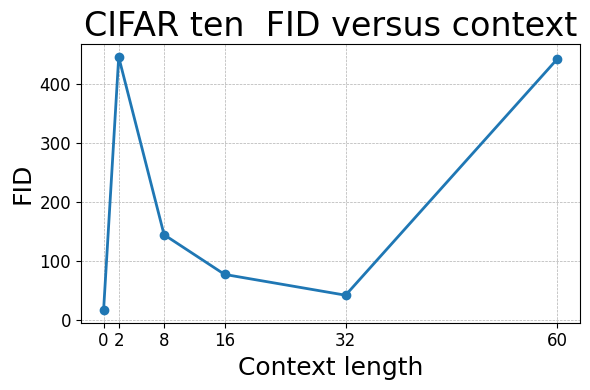

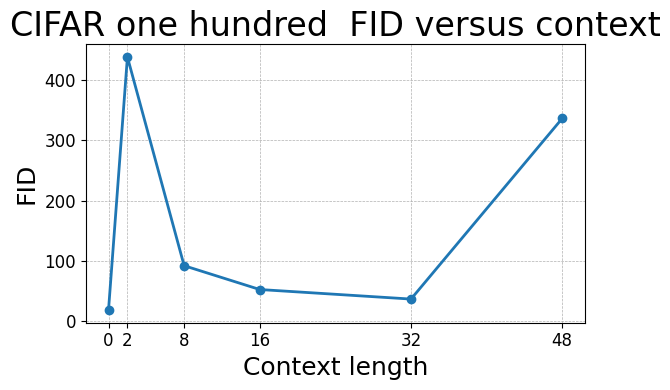

CIFAR ten FID scores
 context        FID
       0  16.083229
       2 446.591766
       8 144.247253
      16  76.744461
      32  41.350334
      60 443.221252

CIFAR one hundred FID scores
 context        FID
       0  18.364862
       2 437.988373
       8  91.948235
      16  52.437782
      32  36.606361
      48 336.151062


In [ ]:
# Cell 10  FID curves for CIFAR-10 and CIFAR-100

if not HAS_FID:
    print("Torchmetrics FID is not available  FID plots will be skipped")
else:
    # knobs that control memory during FID
    FID_TARGET_IMAGES = 5000        # total images per set real and fake
    FID_TOKENS_CAP = 1024            # bound on batch size times context length
    FID_MAX_STEP_BATCH = 512         # bound on how many images go through the denoiser per step
    FID_INCEPTION_BATCH = 512        # bound on how many images go into Inception at once

    def add_block_to_fid(fid_metric, flat_block, ctx_effective, real_flag, image_size):
        # flat_block has shape batch by ctx_effective by dim
        batch, ctx, dim = flat_block.shape
        assert ctx == ctx_effective

        if image_size == 32:
            channels = 3
            height = 32
            width = 32
            imgs = flat_block[:, 0, :].reshape(batch, channels, height, width)
        else:
            raise ValueError("Image size not supported in FID helper")

        imgs = imgs.clamp(0.0, 1.0)
        imgs_uint8 = (imgs * 255.0).to(torch.uint8)

        # feed Inception in small chunks so memory stays under control
        for start in range(0, batch, FID_INCEPTION_BATCH):
            end = min(start + FID_INCEPTION_BATCH, batch)
            fid_metric.update(imgs_uint8[start:end], real=real_flag)

    def fid_curve_for_dataset(
        dataset_name,
        contexts,
        seed_for_fid,
        target_images=FID_TARGET_IMAGES,
        tokens_cap=FID_TOKENS_CAP,
    ):
        # bind dataset specific tensors and hyper parameters
        if dataset_name == "cifar10":
            data = get_cifar10_data()
            test_imgs = data["test_imgs"]
            dim = data["dim"]
            image_size = 32
            noise_std = CIFAR10_NOISE_STD
            model_dir = MODEL_ROOT / "cifar10"
        elif dataset_name == "cifar100":
            data = get_cifar100_data()
            test_imgs = data["test_imgs"]
            dim = data["dim"]
            image_size = 32
            noise_std = CIFAR100_NOISE_STD
            model_dir = MODEL_ROOT / "cifar100"
        else:
            raise ValueError("FID only defined for CIFAR-10 and CIFAR-100")

        test_imgs = test_imgs.to(device=device, dtype=DTYPE)
        total = test_imgs.shape[0]

        scores = []

        for ctx in contexts:
            ctx_effective = max(int(ctx), 1)

            # load or create the model once for this context
            model, _ = train_model_for_dataset(
                dataset_name=dataset_name,
                context_length=ctx,
                seed=seed_for_fid,
                reuse_checkpoint=True,
            )
            model.do_icl = (ctx > 0)
            model.eval()

            fid_metric = FrechetInceptionDistance(
                feature=2048,
                reset_real_features=True,
            ).to(device)

            generator = torch.Generator(device=device)
            generator.manual_seed(0)

            # compute step batch size for the denoiser
            # respect both the token cap and a manual upper bound
            raw_batch = tokens_cap // ctx_effective if tokens_cap // ctx_effective > 0 else ctx_effective
            batch_images = min(FID_MAX_STEP_BATCH, max(ctx_effective, raw_batch))
            if batch_images < ctx_effective:
                batch_images = ctx_effective

            collected = 0
            use_amp = (device.type == "cuda")

            while collected < target_images:
                idx = torch.randint(
                    low=0,
                    high=total,
                    size=(batch_images,),
                    generator=generator,
                    device=device,
                )
                clean_flat = test_imgs[idx]
                clean = clean_flat.view(-1, 1, dim)

                # real images for FID
                add_block_to_fid(
                    fid_metric,
                    clean,
                    ctx_effective=1,
                    real_flag=True,
                    image_size=image_size,
                )

                # fake images from the denoiser
                noisy = clean.clone()
                noisy[:, 0, :] = noisy[:, 0, :] + torch.randn_like(
                    noisy[:, 0, :]
                ) * noise_std

                if ctx_effective > 1:
                    block = noisy.repeat(1, ctx_effective, 1)
                else:
                    block = noisy

                with torch.no_grad():
                    if use_amp:
                        autocast_context = torch.cuda.amp.autocast(dtype=DTYPE)
                    else:
                        autocast_context = torch.cuda.amp.autocast(enabled=False)

                    with autocast_context:
                        recon, _ = model(block)

                if ctx_effective == 1:
                    recon_block = recon.view(-1, 1, dim)
                else:
                    recon_block = recon

                add_block_to_fid(
                    fid_metric,
                    recon_block,
                    ctx_effective=ctx_effective,
                    real_flag=False,
                    image_size=image_size,
                )

                collected += batch_images

            score = float(fid_metric.compute().item())
            scores.append(score)
            print(f"{dataset_name} context {ctx}  FID {score:.2f}")

            del model, fid_metric
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

        return np.asarray(contexts, dtype=np.int64), np.asarray(scores, dtype=np.float64)

    print("Running FID sweeps for CIFAR-10 and CIFAR-100")

    fid_seed = SEED_VALUES[0]

    c10_fid_x, c10_fid_scores = fid_curve_for_dataset(
        "cifar10", CIFAR10_CONTEXTS, seed_for_fid=fid_seed
    )
    c100_fid_x, c100_fid_scores = fid_curve_for_dataset(
        "cifar100", CIFAR100_CONTEXTS, seed_for_fid=fid_seed
    )

    def plot_fid_curve(contexts, scores, title_text):
        plt.figure(figsize=(6, 4))
        plt.plot(contexts, scores, "o-", linewidth=2.0, markersize=6)
        plt.xticks(contexts, [str(int(c)) for c in contexts])
        plt.xlabel("Context length", fontsize=AXIS_FONT_SIZE)
        plt.ylabel("FID", fontsize=AXIS_FONT_SIZE)
        plt.xticks(fontsize=LABEL_FONT_SIZE)
        plt.yticks(fontsize=LABEL_FONT_SIZE)
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.title(title_text, fontsize=TITLE_FONT_SIZE)
        plt.tight_layout()
        plt.show()

    plot_fid_curve(c10_fid_x, c10_fid_scores, "CIFAR-10  FID versus context")
    plot_fid_curve(c100_fid_x, c100_fid_scores, "CIFAR-100  FID versus context")

    print("CIFAR-10 FID scores")
    print(pd.DataFrame({"context": c10_fid_x, "FID": c10_fid_scores}).to_string(index=False))
    print()
    print("CIFAR-100 FID scores")
    print(pd.DataFrame({"context": c100_fid_x, "FID": c100_fid_scores}).to_string(index=False))


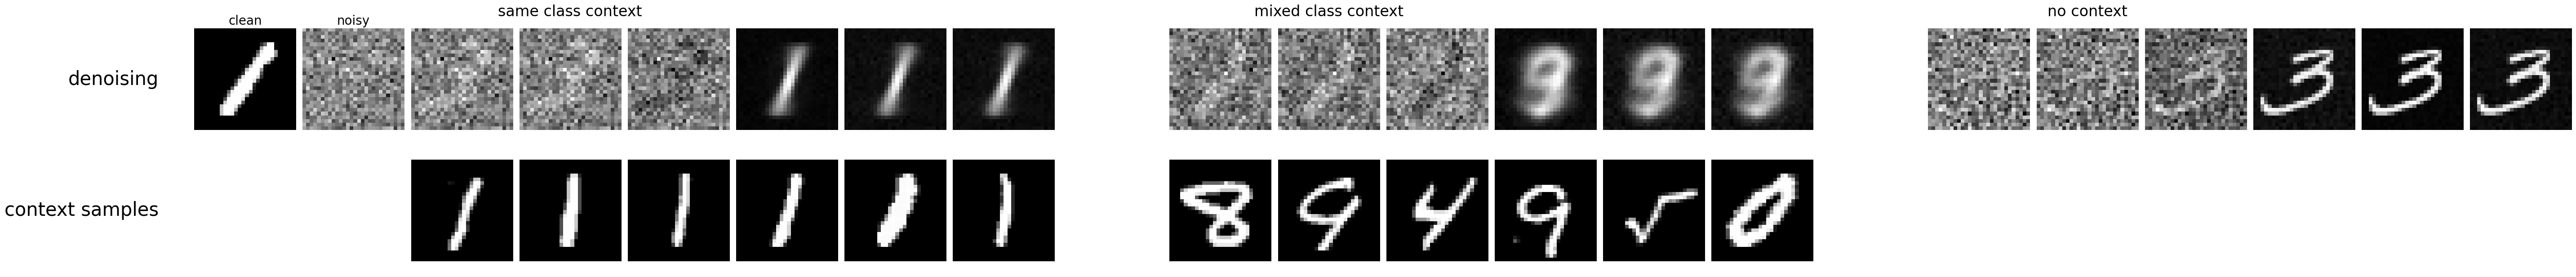

In [ ]:
# Cell 11  mnist visualization  clean noisy same mixed none

def load_mnist_model_for_visualization(context_length, seed):
    data = get_mnist_data()
    witness = data["witness"]
    model_dir = MODEL_ROOT / "mnist"
    model_dir.mkdir(parents=True, exist_ok=True)
    ctx_tag = int(context_length)
    ckpt_path = model_dir / f"denoiser_ctx{ctx_tag}_seed{seed}.pt"

    if ckpt_path.exists():
        model = build_model_for_dataset("mnist", witness)
        state = torch.load(str(ckpt_path), map_location=device)
        # allow checkpoints that omit witness buffers
        model.load_state_dict(state, strict=False)
        model.do_icl = (context_length > 0)
        return model, data

    model, data_cache = train_model_for_dataset(
        dataset_name="mnist",
        context_length=context_length,
        seed=seed,
        reuse_checkpoint=True,
    )
    return model, data_cache


def mnist_visualization_figure(context_length_large=None, seed=None):
    if context_length_large is None:
        context_length_large = max(MNIST_CONTEXTS)
    if seed is None:
        seed = SEED_VALUES[0]

    model_none, data = load_mnist_model_for_visualization(0, seed)
    model_ctx, _ = load_mnist_model_for_visualization(context_length_large, seed)

    test_set = data["test_set"]
    test_labels = data["test_labels"]
    dim = data["dim"]

    idx = random.randint(0, len(test_set) - 1)
    clean_flat, label = test_set[idx]
    clean_flat = clean_flat.to(device=device, dtype=DTYPE)
    label_value = int(label.item())

    same_idx = torch.where(test_labels == label_value)[0]
    diff_idx = torch.where(test_labels != label_value)[0]

    def choose_context_indices(pool, count):
        pool = pool[pool != idx]
        perm = pool[torch.randperm(len(pool))]
        return perm[:count]

    ctx_len = int(context_length_large)

    same_context_indices = choose_context_indices(same_idx, ctx_len - 1)
    mixed_context_indices = choose_context_indices(diff_idx, ctx_len - 1)

    ctx_same_images = [clean_flat.cpu()]
    for i in same_context_indices:
        ctx_same_images.append(test_set[int(i)][0].cpu())
    ctx_mixed_images = [clean_flat.cpu()]
    for i in mixed_context_indices:
        ctx_mixed_images.append(test_set[int(i)][0].cpu())

    clean_block_same = torch.stack(ctx_same_images).view(1, ctx_len, dim).to(
        device=device, dtype=DTYPE
    )
    clean_block_mixed = torch.stack(ctx_mixed_images).view(1, ctx_len, dim).to(
        device=device, dtype=DTYPE
    )

    clean_block_none = clean_flat.view(1, 1, dim).to(device=device, dtype=DTYPE)

    noisy_same = clean_block_same.clone()
    noisy_same[:, 0, :] = noisy_same[:, 0, :] + torch.randn_like(
        noisy_same[:, 0, :]
    ) * MNIST_NOISE_STD

    noisy_mixed = clean_block_mixed.clone()
    noisy_mixed[:, 0, :] = noisy_mixed[:, 0, :] + torch.randn_like(
        noisy_mixed[:, 0, :]
    ) * MNIST_NOISE_STD

    noisy_none = clean_block_none.clone()
    noisy_none[:, 0, :] = noisy_none[:, 0, :] + torch.randn_like(
        noisy_none[:, 0, :]
    ) * MNIST_NOISE_STD

    use_amp = (device.type == "cuda")

    with torch.no_grad():
        if use_amp:
            autocast_context = torch.cuda.amp.autocast(dtype=DTYPE)
        else:
            autocast_context = torch.cuda.amp.autocast(enabled=False)

        with autocast_context:
            _, traj_same = model_ctx(noisy_same)
            _, traj_mixed = model_ctx(noisy_mixed)
            _, traj_none = model_none(noisy_none)

    steps_same = [step[0, 0].detach().cpu() for step in traj_same]
    steps_mixed = [step[0, 0].detach().cpu() for step in traj_mixed]
    steps_none = [step[0, 0].detach().cpu() for step in traj_none]

    def to_image(vec):
        img = vec.view(28, 28).float()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img

    num_layers = NUM_LAYERS
    num_cols_block = num_layers
    num_cols = 2 + 3 * num_cols_block + 2
    num_rows = 2

    cell_size = 2.6
    fig_width = num_cols * cell_size
    fig_height = num_rows * cell_size * 1.2

    plt.figure(figsize=(fig_width, fig_height))

    clean_img = to_image(clean_flat.cpu())
    noisy_img = to_image(noisy_same[0, 0].cpu())

    plt.subplot(num_rows, num_cols, 1)
    plt.imshow(clean_img, cmap="gray")
    plt.axis("off")
    plt.title("clean", fontsize=20)

    plt.subplot(num_rows, num_cols, 2)
    plt.imshow(noisy_img, cmap="gray")
    plt.axis("off")
    plt.title("noisy", fontsize=20)

    def col_offset(group_index):
        return 2 + group_index * (num_cols_block + 1)

    for i in range(num_layers):
        plt.subplot(num_rows, num_cols, col_offset(0) + i + 1)
        plt.imshow(to_image(steps_same[i + 1]), cmap="gray")
        plt.axis("off")

        plt.subplot(num_rows, num_cols, col_offset(1) + i + 1)
        plt.imshow(to_image(steps_mixed[i + 1]), cmap="gray")
        plt.axis("off")

        plt.subplot(num_rows, num_cols, col_offset(2) + i + 1)
        plt.imshow(to_image(steps_none[i + 1]), cmap="gray")
        plt.axis("off")

    for j in range(2):
        plt.subplot(num_rows, num_cols, num_cols + j + 1)
        plt.axis("off")

    max_ctx_show = min(num_layers, ctx_len - 1)

    for i in range(max_ctx_show):
        plt.subplot(num_rows, num_cols, num_cols + col_offset(0) + i + 1)
        plt.imshow(to_image(ctx_same_images[i + 1]), cmap="gray")
        plt.axis("off")

        plt.subplot(num_rows, num_cols, num_cols + col_offset(1) + i + 1)
        plt.imshow(to_image(ctx_mixed_images[i + 1]), cmap="gray")
        plt.axis("off")

    for i in range(num_layers):
        plt.subplot(num_rows, num_cols, num_cols + col_offset(2) + i + 1)
        plt.axis("off")

    plt.subplot(num_rows, num_cols, 1)
    plt.text(
        -0.35,
        0.5,
        "denoising",
        fontsize=30,
        ha="right",
        va="center",
        transform=plt.gca().transAxes,
    )

    plt.subplot(num_rows, num_cols, num_cols + 1)
    plt.text(
        -0.35,
        0.5,
        "context samples",
        fontsize=30,
        ha="right",
        va="center",
        transform=plt.gca().transAxes,
    )

    titles = ["same class context", "mixed class context", "no context"]

    for g, text in enumerate(titles):
        ax = plt.subplot(num_rows, num_cols, col_offset(g) + 2)
        ax.set_title(text, fontsize=24, pad=20)

    plt.subplots_adjust(wspace=0.25)
    plt.tight_layout()
    plt.show()


mnist_visualization_figure()
